# Quantum Optics - Homework 1

## Jan Chelmecki

The task is to display the eigenfunctions of

$$
H = −E_J \cos (\phi - \phi_{ext}) + 4 E_C (n-n_{ext})^2 + \frac{E_L}{2} \phi^2
$$

where $\phi$ and $n$ are conjugate variables henceforth associated to position and momentum, respectively (it is really a matter of language, and I like the good old $x$ and $p$ better).

The strategy will be the following.
1. Define the operators in the position space, since this is how we will want to represent the wavefunctions.
2. Discretize the space with a fine 1D grid - operators will then be finite matrices, making the problem numerically solvable.
3. For the potential, define a diagonal matrix.
4. Approximate the momentum operator $-i\hbar\partial_x$ with finite differences, and initialize the appropriate matrix.
5. Use the above to define the Hamiltionian and diagonalize it.

In [18]:
!pip install qutip

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

In [20]:
def solve(EJ,EC,EL,phi_ext,xmax,N):

    ### discretize space
    x = np.linspace(-xmax,xmax, N)
    dx = x[1]-x[0]

    #define the momentum operators
    p2 = np.zeros((N,N), complex)
    s = -1/(dx)**2
    for i in range(N):
        if i>0:
            p2[i,i-1] = s
        #endif
        p2[i,i] = -2*s
        if i<N-1:
            p2[i,i+1] = s
        #endif
    #end
    T = 4*EC*p2

    ### define the potential
    V_vals = -EJ*np.cos(x-phi_ext) +EL/2 * x**2
    V = np.diag(V_vals)

    H = Qobj(T+V)
    energies, eigenstates = H.eigenstates()

    states=[]
    for n in range(4):
        psi = eigenstates[n].full().flatten()
        psi = psi / np.sqrt(np.sum(np.abs(psi)**2) * dx)  # normalize
        states.append(psi)
    return energies[:4:], states
#end

In [21]:
def show_states(EJ,EC,EL,phi_ext,xmax,N):
    x = np.linspace(-xmax,xmax, N)
    V = -EJ*np.cos(x-phi_ext) +EL/2 * x**2

    energies, states = solve(EJ,EC,EL,phi_ext,xmax,N)
    print("Energies = ", energies)
    plt.plot(x, V)
    for i in range(len(energies)):
        plt.plot(x,energies[i]+np.real(states[i]), label="|"+str(i)+">")
    plt.grid()
    plt.xlabel("$\phi$")
    plt.ylabel("$E/\hbar$ (GHZ)")
    xlim = np.abs(x[np.argmax(V)])
    plt.xlim(-xlim,xlim)
    plt.ylim(np.min(V)-0.2, V[int(N/2)]+1.0)
    plt.legend()
#end

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-2000707374.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi$")
/tmp/ipython-input-2000707374.py:12: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("$E/\hbar$ (GHZ)")


Energies =  [-2.32642161 -2.32461348  1.38182271  1.43547638]


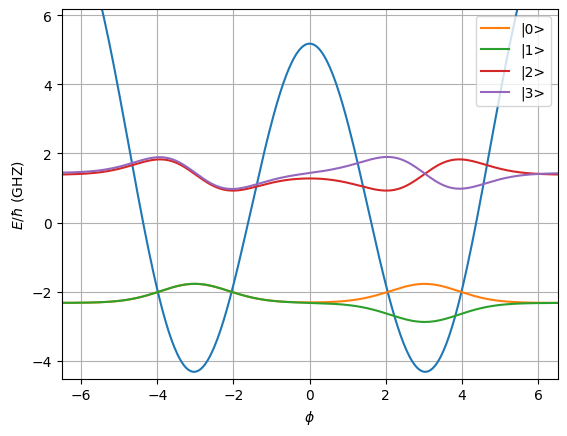

In [22]:
EJ = 5.178 #GHz*h
EC = 0.4144 #GHz*h
EL = 0.18 #GHz*h
phi_ext = np.pi*1.00
n_ext = 0.0

xmax = 10.0
N = 500

show_states(EJ,EC,EL,phi_ext,xmax,N)

Levels $\ket{0}$ and $\ket{1}$ as well as $\ket{2}$ and $\ket{3}$ are almost degenerate and indeed, they would be for an infite well. Here the degeneracy is lifted due to tunneling. In each pair, the symmetric eigenstates has slightly lower energy.

Now, let's plot transition energies as a function of $\phi_{ext}$, since those are the most experimentally relevant characteristic of the system.

Before we do so, let's study the truncation errors, which emerge because
- we are making the space discrete
- we are making the spatial domain finite

Let's look at how the computed value of $E_1-E_0$ changes as we increase the range and the resolution (the choice of looking at this quantity is motivated by the fact that being linked to the tunnelling rate, it depends exponentially on the height of the barrier, and so it should be a good indicator of numerical convergence, as we expect it to be very sensitive). We'll also plot the transition energy $E_2-E_0$, which we do not expect to be small.

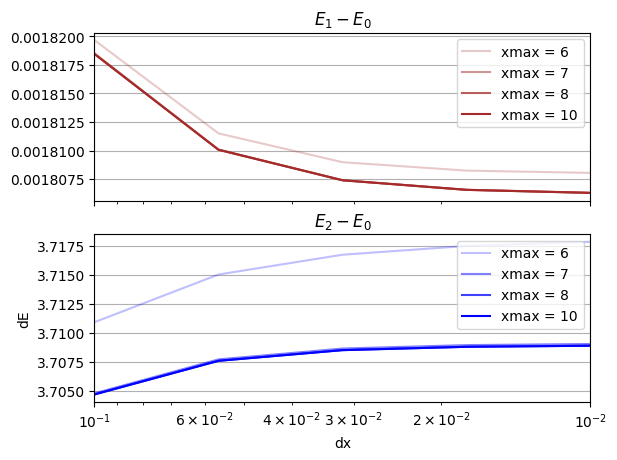

In [36]:
EJ = 5.178 #GHz*h
EC = 0.4144 #GHz*h
EL = 0.18 #GHz*h
phi_ext = np.pi
f, (ax1, ax2) = plt.subplots(2,1, sharex=True)

xmax_list = [6,7,8,10]
dx = np.logspace(-1,-2,5)
for i in range(len(xmax_list)):
  xmax = xmax_list[i]
  dE = []
  dE2 = []
  for d in dx:
      N = 2*int(xmax/d)
      E, states = solve(EJ,EC,EL,phi_ext,xmax,N)
      dE.append(E[1]-E[0])
      dE2.append(E[2]-E[0])
  ax1.semilogx(dx,dE, label="xmax = "+str(xmax), alpha = (i+1)/len(xmax_list), color = 'brown')
  ax2.semilogx(dx,dE2, label="xmax = "+str(xmax), alpha = (i+1)/len(xmax_list), color = 'blue')
ax1.legend(); ax2.legend()
plt.xlabel("dx")
ax1.set_title("$E_1-E_0$")
ax2.set_title("$E_2-E_0$")
plt.ylabel("dE")
#plt.ylabel("$E_1-E_0$ (GHz)"); ax2.ylabel("$E_2-E_1$ (GHz)$")
plt.xlim(0.1,0.01)
ax1.grid(); ax2.grid()


We see that there is no noticible penalty for setting xmax = 8 rather than some larger value (this is due to the superexponential decrease of the wavefunctions due to energy being smaller than V(x), while the latter increases (WKB intuition)). As for dx, I will choose the value of 0.02, since that is where the values seem to settle. This choice is motivated by limitations in CPU power (my laptop broke down, so I am working in google on a borrowed device). For the same reason, I do not explore dx ~ 10^-3. This being said, the numerical accuracy available is absolutely sufficient for my purposes, and I do not need to optimize the code (e.g. use the fact that the matrix is tridiagonal etc).

In [38]:
xmax = 8
dx = 0.02
N = 2*int(xmax/dx)
N

800

<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2868912941.py:18: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi_{ext}/2\pi$")


Text(0, 0.5, 'Drive frequency (GHz)')

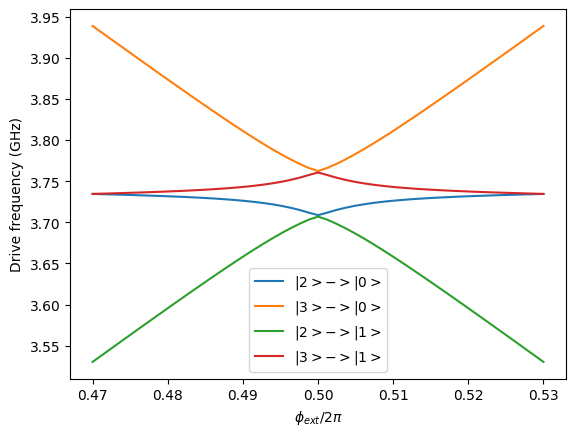

In [39]:
points = 51
phi_ext_list = np.linspace(0.94*np.pi,1.06*np.pi,points)
E_arr = np.zeros((4,points))

for i in range(points):
    EJ = 5.178 #GHz*h
    EC = 0.4144 #GHz*h
    EL = 0.18 #GHz*h
    phi_ext = phi_ext_list[i]
    E, states = solve(EJ,EC,EL,phi_ext,xmax,N)
    E_arr[:,i] = E

plt.plot(phi_ext_list/(2*np.pi),E_arr[2,:]-E_arr[0,:],label="$|2>  ->  |0>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[3,:]-E_arr[0,:],label="$|3>  ->  |0>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[2,:]-E_arr[1,:],label="$|2>  ->  |1>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[3,:]-E_arr[1,:],label="$|3>  ->  |1>$")
plt.legend()
plt.xlabel("$\phi_{ext}/2\pi$")
plt.ylabel("Drive frequency (GHz)")

The interesting part is when the curves almost intersect - this is where tunneling comes in to lift the degeneracy.

<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-3383588329.py:18: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi_{ext}/2\pi$")


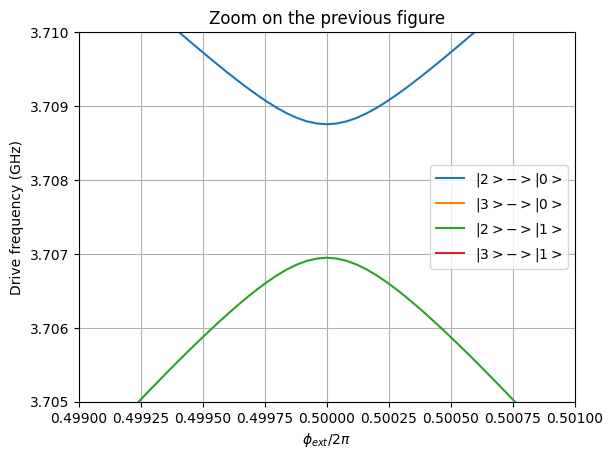

In [40]:
points = 51
phi_ext_list = np.linspace(2*0.499*np.pi,2*0.501*np.pi,points)
E_arr = np.zeros((4,points))

for i in range(points):
    EJ = 5.178 #GHz*h
    EC = 0.4144 #GHz*h
    EL = 0.18 #GHz*h
    phi_ext = phi_ext_list[i]
    E, states = solve(EJ,EC,EL,phi_ext,xmax,N)
    E_arr[:,i] = E

plt.plot(phi_ext_list/(2*np.pi),E_arr[2,:]-E_arr[0,:],label="$|2>  ->  |0>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[3,:]-E_arr[0,:],label="$|3>  ->  |0>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[2,:]-E_arr[1,:],label="$|2>  ->  |1>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[3,:]-E_arr[1,:],label="$|3>  ->  |1>$")
plt.legend()
plt.xlabel("$\phi_{ext}/2\pi$")
plt.ylabel("Drive frequency (GHz)")
plt.xlim(0.499,0.501)
plt.ylim(3.705,3.710)
plt.title("Zoom on the previous figure")
plt.grid()

In [41]:
i = points//2
#print(phi_ext_list[i] == np.pi)
dE = E_arr[1,i]-E_arr[0,i]
print(dE*1000)

1.8066598022472569


Hence for the energy difference $E_1-E_0$ for the symmetric potential is 1.8 MHz.